## 1. Init

In [28]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor() # Convert images to PyTorch tensors
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Classes: {len(classes)}")


Classes: 10


## 2. Sample data

Image batch shape: torch.Size([64, 3, 32, 32])


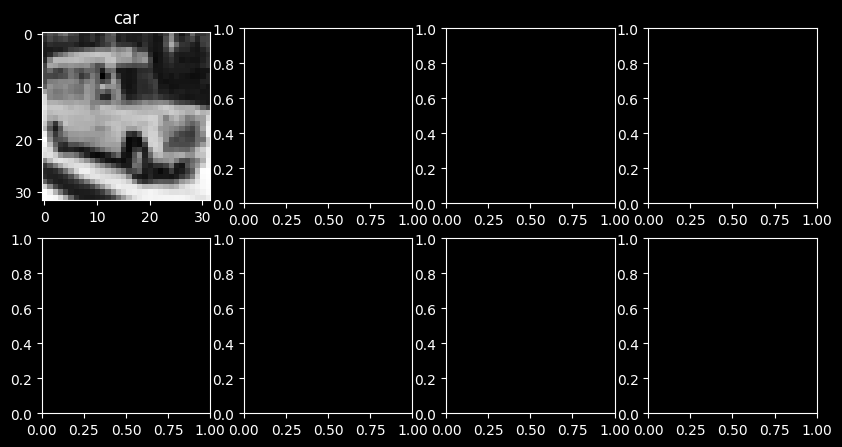

<Figure size 640x480 with 0 Axes>

In [29]:
import matplotlib.pyplot as plt

image, labels = next(iter(train_loader))
print (f"Image batch shape: {image.shape}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5)) # Create a figure with 1 row and 5 columns

for i, ax in enumerate(axes.flat):
    img = image[i].permute(1, 2, 0) # Convert from (C, H, W) to (H, W, C)
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    plt.show()

plt.tight_layout()
plt.show()

## 3. CIFAR CNN

In [30]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # Input channels: 3 (RGB), Output channels: 16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Input channels: 16, Output channels: 32

        self.pool = nn.MaxPool2d(2, 2) # Max pooling layer with kernel size 2 and stride 2

        self.relu = nn.ReLU() # ReLU activation function

        self.flatten = nn.Flatten() # Flatten layer to convert 2D feature maps to 1D feature vectors

        self.fc1 = nn.Linear(32 * 8 * 8, 128) # Fully connected layer with input size 32*8*8 and output size 128
        self.fc2 = nn.Linear(128, 10) # Fully connected layer with input size 128 and output size 10 (number of classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # [64, 16, 16, 16]
        x = self.pool(self.relu(self.conv2(x))) # [64, 32, 8, 8]
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CIFAR_CNN()
print(model)

CIFAR_CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Training


In [31]:
loss_fn = nn.CrossEntropyLoss() # Define the loss function (cross-entropy loss for classification)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Epoch - Learning cycle

num_epochs = 10
for epoch in range(num_epochs):
    total_loss = 0

    for images, labels in train_loader:
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.5583
Epoch 2/10, Loss: 1.2340
Epoch 3/10, Loss: 1.0925
Epoch 4/10, Loss: 0.9851
Epoch 5/10, Loss: 0.9086
Epoch 6/10, Loss: 0.8479
Epoch 7/10, Loss: 0.8013
Epoch 8/10, Loss: 0.7547
Epoch 9/10, Loss: 0.7126
Epoch 10/10, Loss: 0.6746


## 5. Evaluation

In [32]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images)
        guesses = predictions.argmax(dim=1)

        correct += (guesses == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.6829
